## 1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets...

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request

sns.set_theme(style="whitegrid", palette="muted")

dataset_link = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
local_file = Path("cleveland_heart_data.csv")

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

if not local_file.is_file():
    print("Локального файлу не знайдено. Завантаження з UCI...")
    urllib.request.urlretrieve(dataset_link, local_file)
    print("Завантаження завершено.")
else:
    print("Файл знайдено локально.")

heart_df = pd.read_csv(local_file, names=columns, na_values="?")

print(f"Розмірність датасету: {heart_df.shape}")
display(heart_df.head())

Локального файлу не знайдено. Завантаження з UCI...
Завантаження завершено.
Розмірність датасету: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Здійснити Data Cleaning

In [4]:
print("Пропуски до обробки:\n", heart_df.isna().sum()[heart_df.isna().sum() > 0])


median_ca_value = heart_df['ca'].median()
heart_df['ca'] = heart_df['ca'].fillna(median_ca_value)

mode_thal_value = heart_df['thal'].mode()[0]
heart_df['thal'] = heart_df['thal'].fillna(mode_thal_value)

# Фінальна перевірка
print("\nПропуски після очищення:", heart_df.isna().sum().max())

Пропуски до обробки:
 ca      4
thal    2
dtype: int64

Пропуски після обробки (має бути 0): 0


## 3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

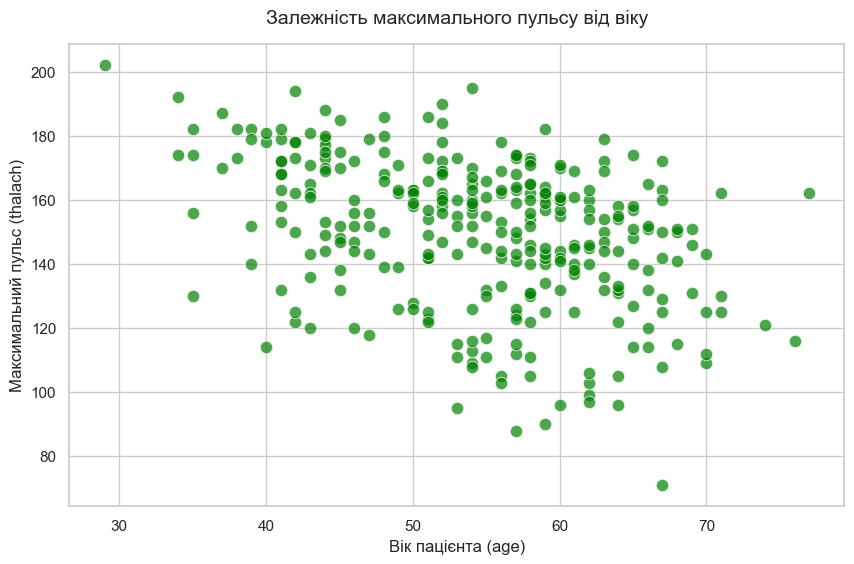

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=heart_df, x='age', y='thalach', alpha=0.7, color='green', s=80)

plt.title("Залежність максимального пульсу від віку", fontsize=14, pad=15)
plt.xlabel("Вік пацієнта (age)", fontsize=12)
plt.ylabel("Максимальний пульс (thalach)", fontsize=12)
plt.show()

## 4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

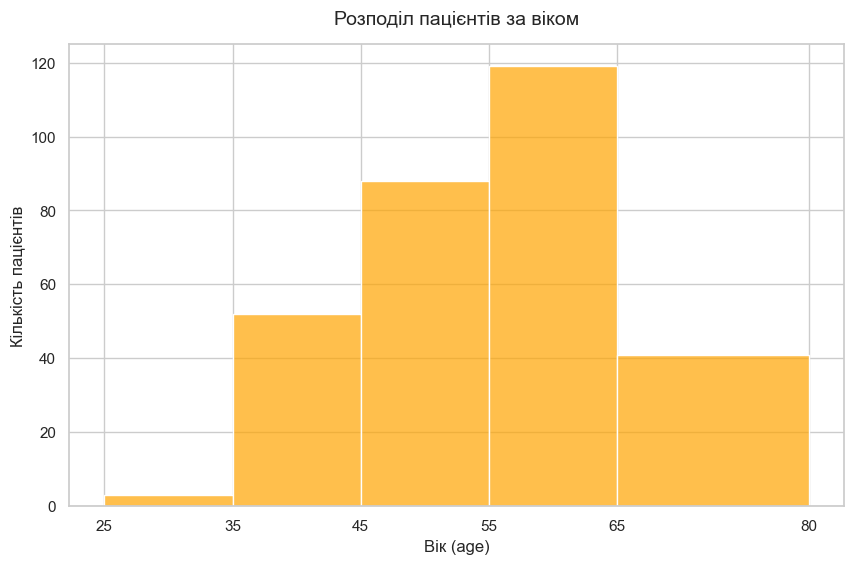

In [6]:
plt.figure(figsize=(10, 6))

# Задаємо межі для 5 діапазонів 
custom_bins = [25, 35, 45, 55, 65, 80]

sns.histplot(data=heart_df, x='age', bins=custom_bins, color='orange', alpha=0.7)

plt.title("Розподіл пацієнтів за віком", fontsize=14, pad=15)
plt.xlabel("Вік (age)", fontsize=12)
plt.ylabel("Кількість пацієнтів", fontsize=12)

plt.xticks(custom_bins) 

plt.show()

## 5. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 


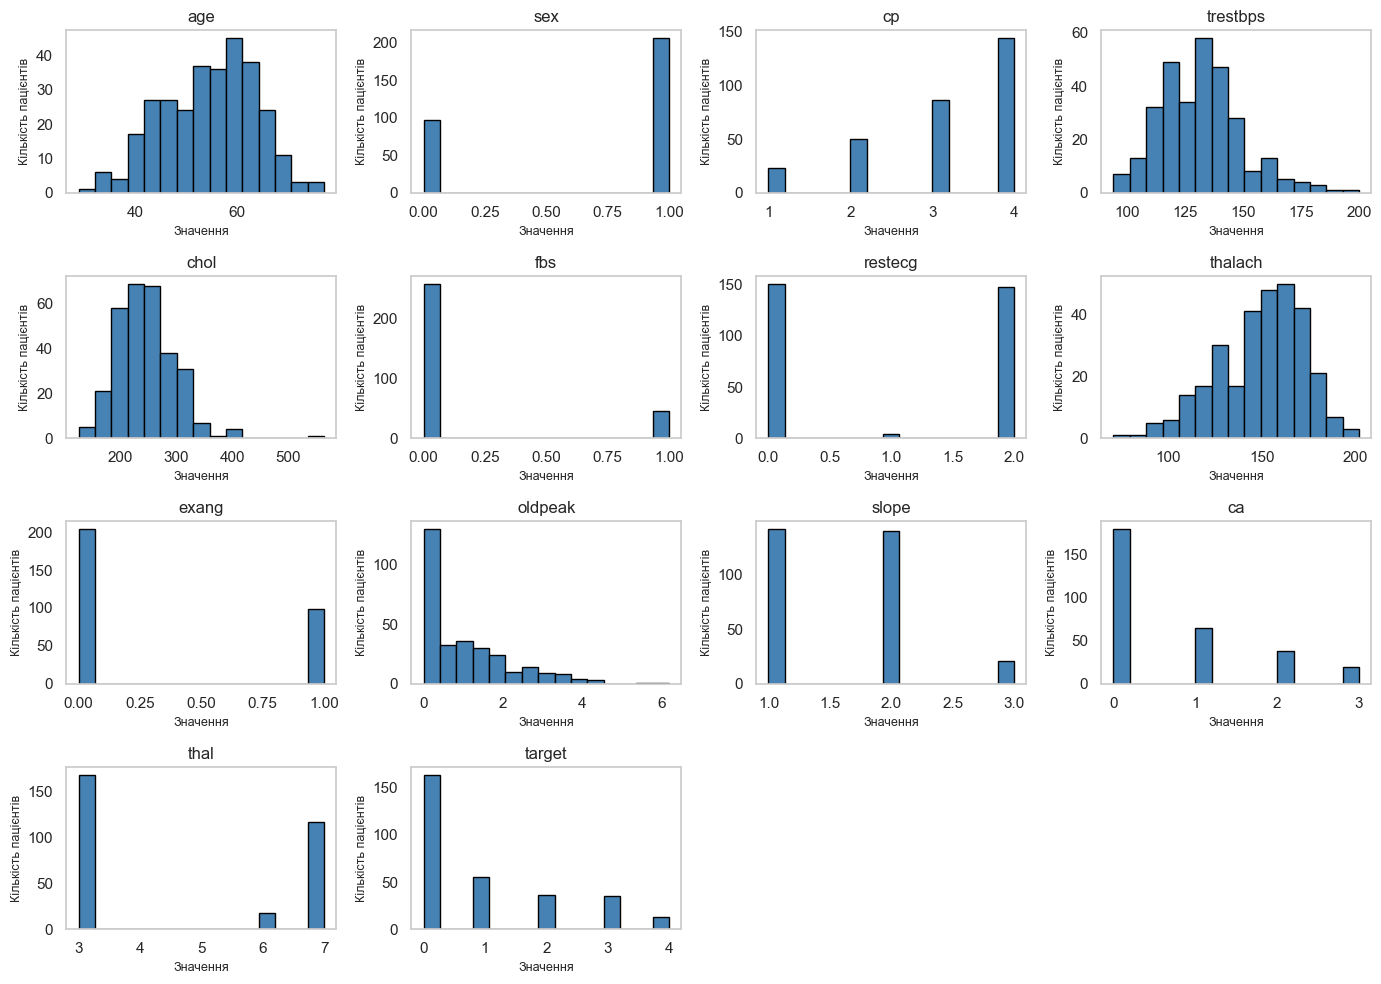

In [12]:
axes = heart_df.hist(
    bins=15, 
    color='steelblue', 
    edgecolor='black', 
    linewidth=1.0,
    grid=False,
    figsize=(14, 10)
)

for row in axes:
    for ax in row:
        ax.set_xlabel("Значення", fontsize=9)
        ax.set_ylabel("Кількість пацієнтів", fontsize=9)

plt.tight_layout()
plt.show()

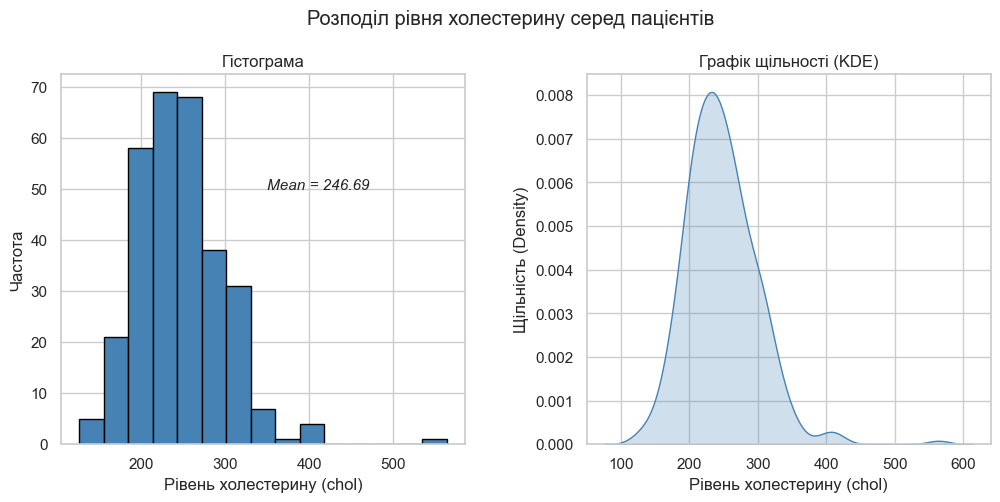

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Розподіл рівня холестерину серед пацієнтів")
fig.subplots_adjust(top=0.85, wspace=0.3)

ax1.set_xlabel("Рівень холестерину (chol)")
ax1.set_ylabel("Частота")
ax1.set_title("Гістограма", fontsize=12)

mean_chol = round(heart_df['chol'].mean(), 2)
ax1.text(350, 50, f'Mean = {mean_chol}', fontsize=11, fontstyle='italic')

ax1.hist(heart_df['chol'], color='steelblue', bins=15, edgecolor='black', linewidth=1)

ax2.set_xlabel("Рівень холестерину (chol)")
ax2.set_ylabel("Щільність (Density)")
ax2.set_title("Графік щільності (KDE)", fontsize=12)

sns.kdeplot(heart_df['chol'], ax=ax2, fill=True, color='steelblue')

plt.show()

## 6. Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

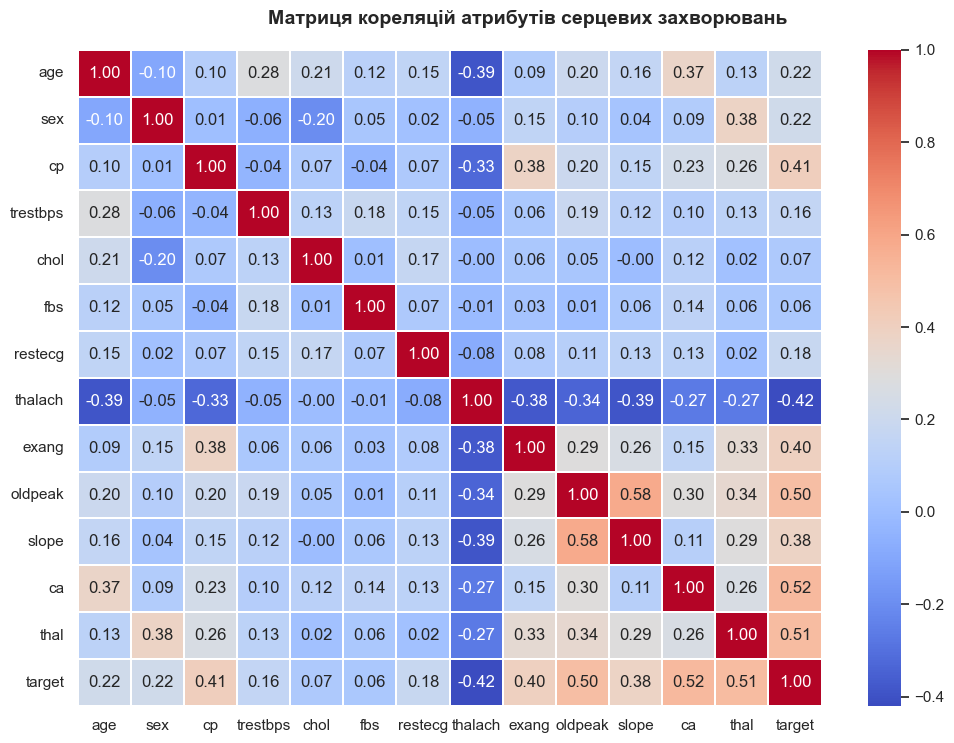

In [14]:
f, ax = plt.subplots(figsize=(12, 8))

corr = heart_df.select_dtypes(include=[np.number]).corr()

hm = sns.heatmap(round(corr, 2), annot=True, ax=ax, cmap="coolwarm", fmt='.2f', linewidths=.05)

f.subplots_adjust(top=0.93)
t = f.suptitle('Матриця кореляцій атрибутів серцевих захворювань', fontsize=14, fontweight='bold')

plt.show()

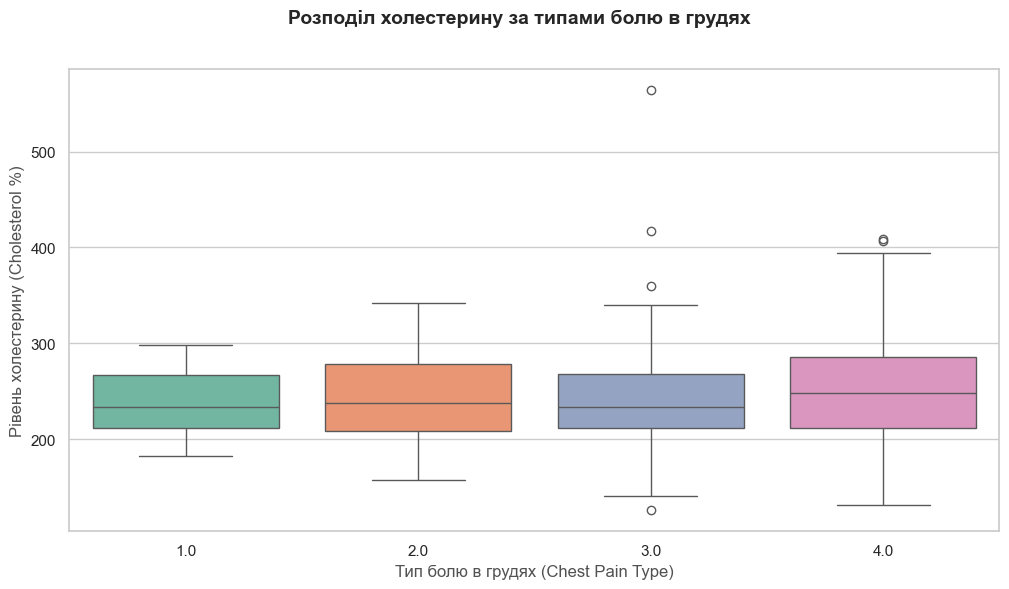

In [16]:
f, (ax) = plt.subplots(1, 1, figsize=(12, 6))

sns.boxplot(x="cp", y="chol", hue="cp", data=heart_df, ax=ax, palette="Set2", legend=False)

f.suptitle('Розподіл холестерину за типами болю в грудях', fontsize=14, fontweight='bold')
ax.set_xlabel("Тип болю в грудях (Chest Pain Type)", size=12, alpha=0.8)
ax.set_ylabel("Рівень холестерину (Cholesterol %)", size=12, alpha=0.8)

plt.show()

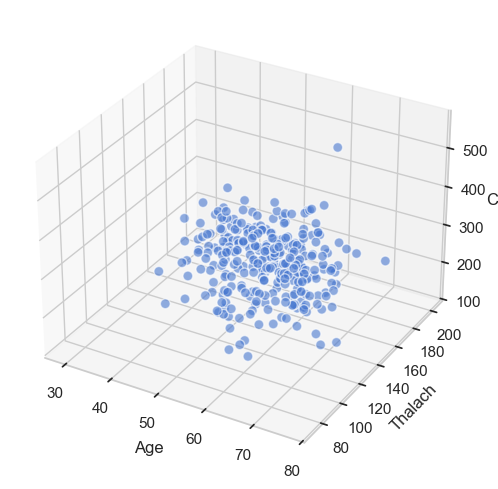

In [17]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

xs = heart_df['age']
ys = heart_df['thalach']
zs = heart_df['chol']

ax.scatter(xs, ys, zs, s=50, alpha=0.6, edgecolors='w')

ax.set_xlabel('Age')
ax.set_ylabel('Thalach')
ax.set_zlabel('Chol')

plt.show()

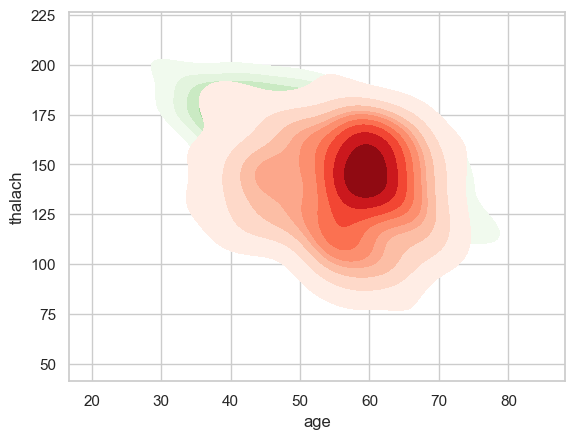

In [20]:
sick_people = heart_df[heart_df['target'] > 0]
healthy_people = heart_df[heart_df['target'] == 0]

ax = sns.kdeplot(x=healthy_people['age'], y=healthy_people['thalach'], 
                 cmap="Greens", fill=True, thresh=0.05)

ax = sns.kdeplot(x=sick_people['age'], y=sick_people['thalach'], 
                 cmap="Reds", fill=True, thresh=0.05)

plt.show()

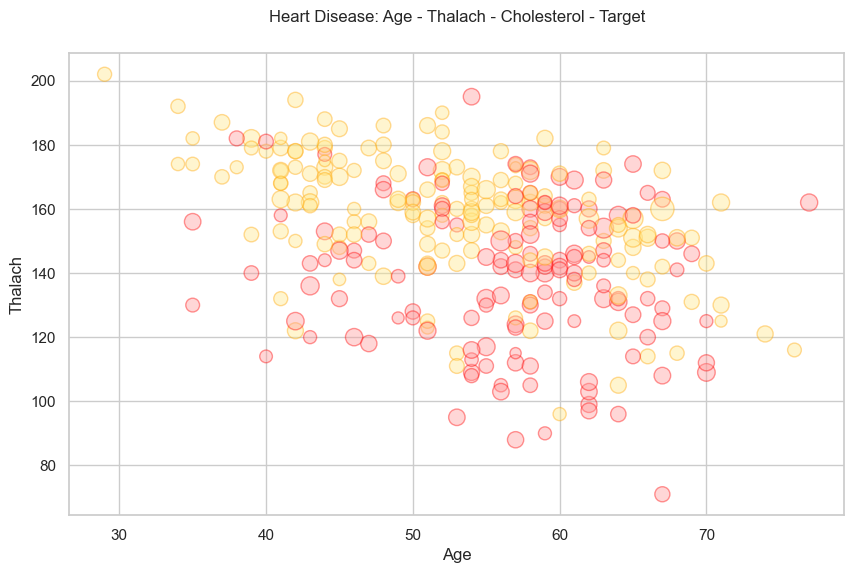

In [21]:
size = heart_df['chol'] * 0.5

fill_colors = ['#FF9999' if t > 0 else '#FFE888' for t in list(heart_df['target'])]
edge_colors = ['red' if t > 0 else 'orange' for t in list(heart_df['target'])]

plt.figure(figsize=(10, 6))
plt.scatter(heart_df['age'], heart_df['thalach'], s=size,
            alpha=0.4, color=fill_colors, edgecolors=edge_colors)

plt.xlabel('Age')
plt.ylabel('Thalach')
plt.title('Heart Disease: Age - Thalach - Cholesterol - Target', y=1.05)

plt.show()

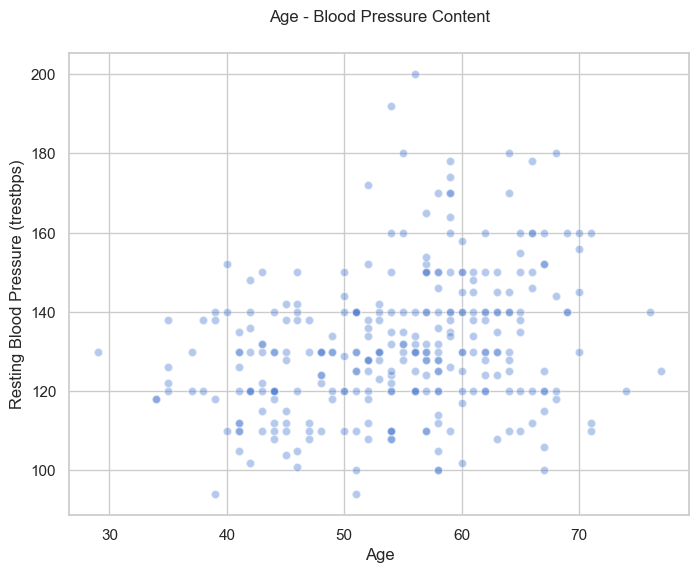

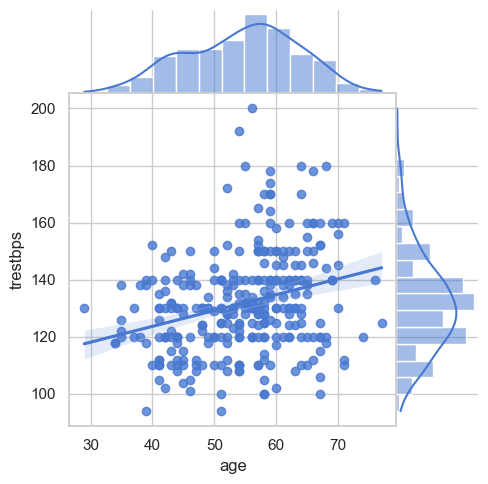

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(heart_df['age'], heart_df['trestbps'], alpha=0.4, edgecolors='w')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure (trestbps)')
plt.title('Age - Blood Pressure Content', y=1.05)
plt.show()

jp = sns.jointplot(x='age', y='trestbps', data=heart_df,
                   kind='reg', space=0, height=5, ratio=4)
plt.show()